R_hat (h): 1.0005512337301024
R_hat (Omega): 1.0020042210725535
Best h: 0.7029408510850289
Best Omega: 0.29634983087651684


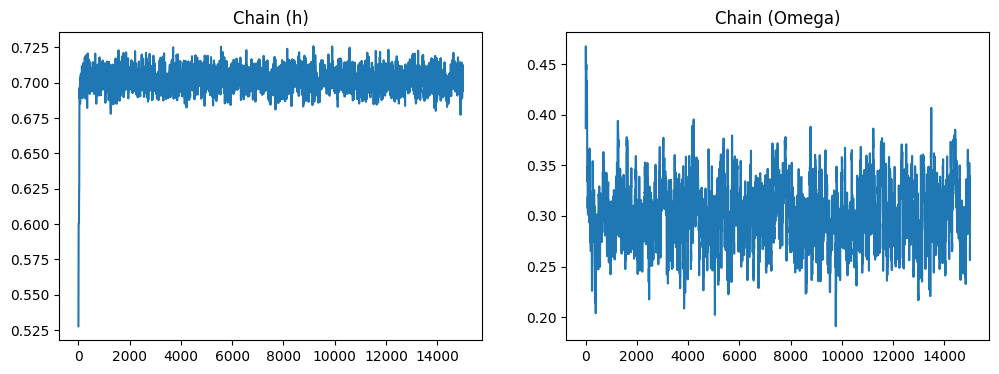

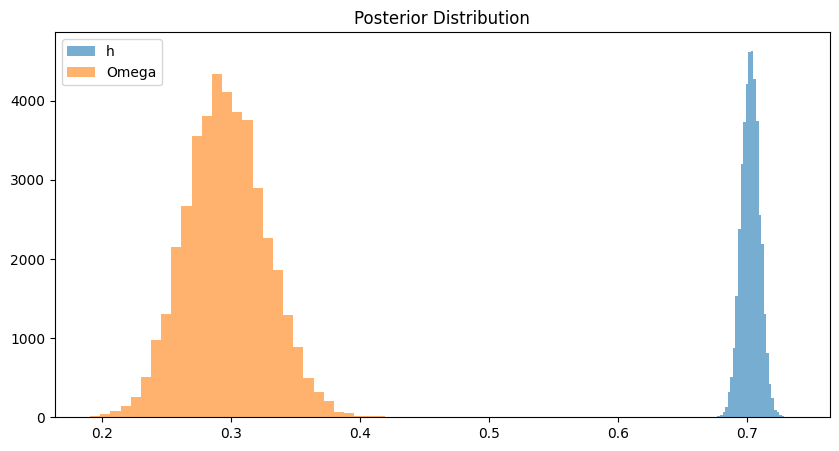

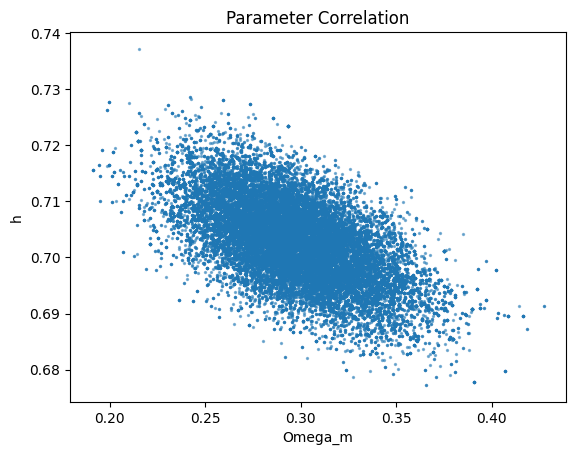

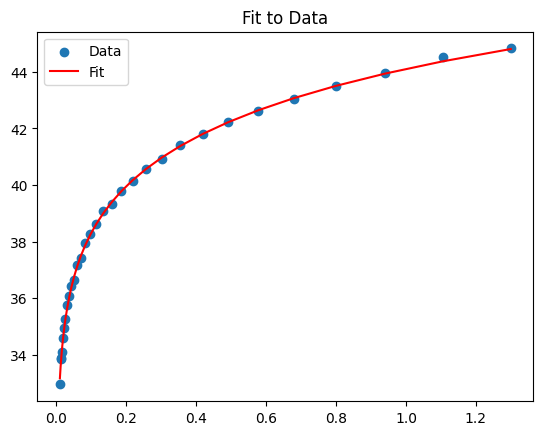

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# =============================
# LOAD DATA
# =============================
data = np.loadtxt("jla_mub_0.txt")
cov_matx = np.loadtxt("jla_mub_covmatrix.txt")

z = data[:,0]
Mu = data[:,1]

cov = cov_matx.reshape(31,31)
InvC = np.linalg.inv(cov)

# =============================
# CONSTANTS
# =============================
H0 = 100
c = 3e5
n_steps = 15000

# =============================
# MODEL
# =============================
def eta(a, omega):
    s = ((1-omega)/omega)**(1/3)
    x = np.sqrt(s**3 + 1)
    x4 = (1/(a**4)) - 0.1540*(s/a**3) + 0.4304*(s**2/a**2) + 0.19097*(s**3/a) + 0.066941*s**4
    return 2*x*(x4**(-1/8))

def lum_dist(z, omega):
    g1 = 1+z
    g2 = 1/g1
    return (c/H0)*g1*(eta(1,omega)-eta(g2,omega))

def mu_model(z, omega, h):
    return 25 - 5*np.log10(h) + 5*np.log10(lum_dist(z, omega))

# =============================
# LIKELIHOOD (CORRECT)
# =============================
def log_like(omega, h):
    if not (0 < omega < 1 and 0 < h < 1):
        return -np.inf
    mu_th = mu_model(z, omega, h)
    diff = Mu - mu_th
    chi2 = diff.T @ InvC @ diff
    return -0.5 * chi2

# =============================
# MCMC (MULTI-CHAIN)
# =============================
def run_mcmc(n_chains=4, steps=10000):
    chains_h = []
    chains_o = []

    for j in range(n_chains):
        h = np.zeros(steps)
        o = np.zeros(steps)

        h[0] = np.random.uniform(0.5,0.9)
        o[0] = np.random.uniform(0.1,0.5)

        for i in range(1,steps):
            h_prop = np.random.normal(h[i-1], 0.02)
            o_prop = np.random.normal(o[i-1], 0.02)

            logp_old = log_like(o[i-1], h[i-1])
            logp_new = log_like(o_prop, h_prop)

            if np.log(np.random.rand()) < (logp_new - logp_old):
                h[i] = h_prop
                o[i] = o_prop
            else:
                h[i] = h[i-1]
                o[i] = o[i-1]

        chains_h.append(h)
        chains_o.append(o)

    return np.array(chains_h), np.array(chains_o)

# =============================
# RUN
# =============================
chains_h, chains_o = run_mcmc(4, n_steps)

burn = int(0.3*n_steps)
h_samples = chains_h[:,burn:].flatten()
o_samples = chains_o[:,burn:].flatten()

# =============================
# GELMAN-RUBIN (CORRECT)
# =============================
def gelman_rubin(chains):
    m, n = chains.shape

    chain_means = np.mean(chains, axis=1)
    grand_mean = np.mean(chain_means)

    B = n * np.var(chain_means, ddof=1)
    W = np.mean(np.var(chains, axis=1, ddof=1))

    var_hat = ((n-1)/n)*W + (B/n)
    R_hat = np.sqrt(var_hat / W)

    return R_hat

R_h = gelman_rubin(chains_h[:,burn:])
R_o = gelman_rubin(chains_o[:,burn:])

print("R_hat (h):", R_h)
print("R_hat (Omega):", R_o)

# =============================
# BEST FIT
# =============================
best_h = np.mean(h_samples)
best_o = np.mean(o_samples)

print("Best h:", best_h)
print("Best Omega:", best_o)

# =============================
# PLOTS
# =============================

# Chains
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(chains_h[0])
plt.title("Chain (h)")

plt.subplot(1,2,2)
plt.plot(chains_o[0])
plt.title("Chain (Omega)")
plt.show()

# Posterior
plt.figure(figsize=(10,5))
plt.hist(h_samples, bins=30, alpha=0.6, label='h')
plt.hist(o_samples, bins=30, alpha=0.6, label='Omega')
plt.legend()
plt.title("Posterior Distribution")
plt.show()

# Correlation
plt.scatter(o_samples, h_samples, s=2, alpha=0.5)
plt.xlabel("Omega_m")
plt.ylabel("h")
plt.title("Parameter Correlation")
plt.show()

# Fit
plt.scatter(z, Mu, label='Data')
plt.plot(z, mu_model(z, best_o, best_h), color='r', label='Fit')
plt.legend()
plt.title("Fit to Data")
plt.show()